# Out-of-Sample Evaluation of LSTM Forecasting Models

This notebook reproduces the out-of-sample forecast accuracy and trading performance results used in the final report. It evaluates four LSTM variants — baseline, jitter, TimeGAN, and VAE-TimeGAN — across three feature specifications:

- WTI only
- WTI with TB3M
- WTI with all covariates

For forecast accuracy, the notebook also loads the benchmark model outputs for AR(3), ADL(1,1), and Full ADL from saved CSV files. In addition, robustness checks are conducted by excluding the COVID-19 crash window from February 2020 to June 2020.

## 1. Setup and Imports

This section imports the Python packages used throughout the notebook and defines the shared configuration, including file paths, model names, and the COVID exclusion window used later for robustness checks.

In [9]:
# =========================================================
# 1. Setup and imports
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Notebook is to be run from forecast_evaluation/
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent

LSTM_RESULTS_DIR = PROJECT_ROOT / "lstm_src" / "results"
BENCHMARK_RESULTS_DIR = PROJECT_ROOT / "benchmark" / "results"

MODEL_COLS = ["normal", "jitter", "timegan", "vaetimegan"]
ACTUAL_COL = "actual"

COVID_START = "2020-02-01"
COVID_END = "2020-06-01"

## 2. Helper Functions

To improve transparency and reduce repetition, the notebook uses a set of reusable helper functions for the following tasks:

- loading model result files
- merging outputs across LSTM variants
- plotting forecast comparisons
- computing forecast accuracy metrics
- filtering the COVID crash period
- formatting tables for display

These functions are used consistently across all three feature specifications.

In [10]:
# =========================================================
# 2. Helper functions
# =========================================================

def rename_cols(df, tag):
    return df.rename(columns={
        "actual": f"actual_{tag}",
        "predicted": f"predicted_{tag}"
    })


def rename_pred_only(df, tag):
    return df.rename(columns={"predicted": f"predicted_{tag}"})


def load_results_csv(filename, base_dir):
    df = pd.read_csv(base_dir / filename)
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
    return df


def build_variant_df(normal_file, jitter_file, timegan_file, vaetimegan_file, merge_on="Date"):
    """
    Build a merged evaluation dataframe for LSTM variants with columns:
    test_index, date, actual, normal, jitter, timegan, vaetimegan
    """
    normal = load_results_csv(normal_file, LSTM_RESULTS_DIR)
    jitter = rename_pred_only(load_results_csv(jitter_file, LSTM_RESULTS_DIR), "jitter")
    timegan = rename_pred_only(load_results_csv(timegan_file, LSTM_RESULTS_DIR), "timegan")
    vaetimegan = rename_pred_only(load_results_csv(vaetimegan_file, LSTM_RESULTS_DIR), "vaetimegan")

    normal = normal.rename(columns={"predicted": "predicted_normal"})

    if merge_on == "test_index":
        df = normal.merge(
            jitter[["test_index", "predicted_jitter", "Date"]],
            on="test_index",
            how="left"
        )

        df["Date"] = pd.to_datetime(df["Date"])
        timegan["Date"] = pd.to_datetime(timegan["Date"])
        vaetimegan["Date"] = pd.to_datetime(vaetimegan["Date"])

        df = (
            df
            .merge(timegan[["Date", "predicted_timegan"]], on="Date", how="left")
            .merge(vaetimegan[["Date", "predicted_vaetimegan"]], on="Date", how="left")
        )

    elif merge_on == "Date":
        for temp_df in [normal, jitter, timegan, vaetimegan]:
            temp_df["Date"] = pd.to_datetime(temp_df["Date"])

        df = (
            normal
            .merge(jitter[["Date", "predicted_jitter"]], on="Date", how="left")
            .merge(timegan[["Date", "predicted_timegan"]], on="Date", how="left")
            .merge(vaetimegan[["Date", "predicted_vaetimegan"]], on="Date", how="left")
        )
    else:
        raise ValueError("merge_on must be either 'Date' or 'test_index'.")

    df = df.rename(columns={"Date": "date"})

    df = df[[
        "test_index",
        "date",
        "actual",
        "predicted_normal",
        "predicted_jitter",
        "predicted_timegan",
        "predicted_vaetimegan"
    ]].copy()

    df = df.rename(columns={
        "predicted_normal": "normal",
        "predicted_jitter": "jitter",
        "predicted_timegan": "timegan",
        "predicted_vaetimegan": "vaetimegan"
    })

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    return df


def plot_forecast_comparison(df, title):
    """
    Plot actual vs LSTM variant forecasts.
    """
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, 5.5))

    ax.plot(df["date"], df["actual"], label="Actual", linewidth=2.2)
    ax.plot(df["date"], df["normal"], label="Baseline (No Augmentation)", linewidth=1.5, linestyle="-")
    ax.plot(df["date"], df["jitter"], label="Jitter", linewidth=1.5, linestyle="--")
    ax.plot(df["date"], df["timegan"], label="TimeGAN", linewidth=1.5, linestyle="-.")
    ax.plot(df["date"], df["vaetimegan"], label="VAE-TimeGAN", linewidth=1.5, linestyle=":")

    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("Log-differenced WTI price", fontsize=11)
    ax.set_title(title, fontsize=12, pad=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.xticks(rotation=45, fontsize=10)
    plt.yticks(fontsize=10)

    ax.legend(frameon=False, fontsize=10, loc="best")
    plt.tight_layout()
    plt.show()


def compute_accuracy_metrics_from_wide_df(df, actual_col="actual", model_cols=None):
    """
    Compute RMSE, MAE, and Directional Accuracy for LSTM variant columns.
    """
    if model_cols is None:
        exclude_cols = {actual_col, "date", "Date", "test_index"}
        model_cols = [col for col in df.columns if col not in exclude_cols]

    actual = df[actual_col].astype(float)
    rows = []

    for model in model_cols:
        predicted = df[model].astype(float)

        rmse = np.sqrt(mean_squared_error(actual, predicted))
        mae = mean_absolute_error(actual, predicted)
        da = (np.sign(actual) == np.sign(predicted)).mean() * 100

        rows.append({
            "Model": model,
            "RMSE": rmse,
            "MAE": mae,
            "Directional Accuracy (DA)": da
        })

    return pd.DataFrame(rows)


def compute_accuracy_metrics_from_results_df(results_df, model_name):
    """
    Compute RMSE, MAE, and Directional Accuracy from benchmark result CSVs
    with columns: Date, actual, predicted
    """
    df = results_df.copy()

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])

    actual = df["actual"].astype(float)
    predicted = df["predicted"].astype(float)

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    da = (np.sign(actual) == np.sign(predicted)).mean() * 100

    return pd.DataFrame([{
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "Directional Accuracy (DA)": da
    }])


def filter_exclude_window(df, start_date=None, end_date=None, date_col="date"):
    """
    Exclude observations between start_date and end_date inclusive.
    """
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    out = out.sort_values(date_col).reset_index(drop=True)

    if start_date is not None and end_date is not None:
        start_date = pd.to_datetime(start_date)
        end_date = pd.to_datetime(end_date)
        mask = (out[date_col] < start_date) | (out[date_col] > end_date)
        out = out.loc[mask].reset_index(drop=True)

    return out


def format_accuracy_metrics_table(metrics_df):
    out = metrics_df.copy()
    out["RMSE"] = out["RMSE"].map(lambda x: f"{x:.3f}")
    out["MAE"] = out["MAE"].map(lambda x: f"{x:.4f}")
    out["Directional Accuracy (DA)"] = out["Directional Accuracy (DA)"].map(lambda x: f"{x:.1f}%")
    return out

def build_benchmark_results_df(pred_df, reference_df, model_name):
    """
    Reconstruct a benchmark results dataframe with columns:
    Date, actual, predicted

    Parameters
    ----------
    pred_df : pd.DataFrame
        Benchmark CSV loaded from disk. Expected to contain only one column
        of predictions, or a column named 'predicted'.
    reference_df : pd.DataFrame
        Corresponding merged LSTM evaluation dataframe containing the correct
        date and actual columns.
    model_name : str
        Used only for error messages.
    """
    pred_df = pred_df.copy()
    reference_df = reference_df.copy()

    # Case 1: if CSV already has a column named 'predicted'
    if "predicted" in pred_df.columns:
        pred_series = pred_df["predicted"].reset_index(drop=True)

    # Case 2: single unnamed/default column
    elif pred_df.shape[1] == 1:
        pred_series = pred_df.iloc[:, 0].reset_index(drop=True)

    else:
        raise ValueError(
            f"{model_name}: benchmark CSV must contain either a single prediction column "
            f"or a column explicitly named 'predicted'."
        )

    ref = reference_df[["date", "actual"]].copy().reset_index(drop=True)

    if len(pred_series) != len(ref):
        raise ValueError(
            f"{model_name}: length mismatch between benchmark predictions ({len(pred_series)}) "
            f"and reference dataframe ({len(ref)})."
        )

    out = pd.DataFrame({
        "Date": pd.to_datetime(ref["date"]),
        "actual": ref["actual"].astype(float),
        "predicted": pred_series.astype(float)
    })

    return out

## 3. Build Evaluation Datasets for LSTM Variants

The next step is to construct the three evaluation datasets used throughout the notebook. Each dataset contains:

- the realized out-of-sample return (`actual`)
- the baseline LSTM forecast (`normal`)
- the jitter-augmented forecast (`jitter`)
- the TimeGAN-augmented forecast (`timegan`)
- the VAE-TimeGAN forecast (`vaetimegan`)

These datasets correspond to the three model specifications used in the report:

1. WTI only
2. WTI with TB3M
3. WTI with all covariates

In [11]:
# =========================================================
# 3. Build evaluation dataframes for LSTM variants
# =========================================================

# WTI only
df1 = build_variant_df(
    normal_file="lstm_test_results.csv",
    jitter_file="lstm_test_jitter_results.csv",
    timegan_file="lstm_test_timegan_results.csv",
    vaetimegan_file="lstm_test_vaetimegan_results.csv",
    merge_on="test_index"
)

# WTI + TB3M
df2 = build_variant_df(
    normal_file="lstm-1_results.csv",
    jitter_file="lstm-1-jitter_results.csv",
    timegan_file="lstm-1-timegan_results.csv",
    vaetimegan_file="lstm-1-vaetimegan_results.csv",
    merge_on="Date"
)

# All covariates
df3 = build_variant_df(
    normal_file="lstm-8_results.csv",
    jitter_file="lstm-8-jitter_results.csv",
    timegan_file="lstm-8-timegan_results.csv",
    vaetimegan_file="lstm-8-vaetimegan_results.csv",
    merge_on="Date"
)

print("WTI only")
display(df1.head())

print("TB3M")
display(df2.head())

print("All covariates")
display(df3.head())

WTI only


,test_index,date,actual,normal,jitter,timegan,vaetimegan
0,408,2020-02-01,-0.129368,-0.134410,-0.095768,-0.107499,-0.123832
1,409,2020-03-01,-0.548254,-0.391728,-0.384119,-0.238859,-0.428196
2,410,2020-04-01,-0.568125,-4.403046,-4.757118,-3.902027,-3.551772
3,411,2020-05-01,0.545621,-2.237060,-1.931571,-2.552425,-3.653004
4,412,2020-06-01,0.293704,-0.655051,-0.446201,0.040100,-0.358767


TB3M


,test_index,date,actual,normal,jitter,timegan,vaetimegan
0,408,2020-02-01,-0.129368,-0.105016,-0.104418,-0.155670,-0.191981
1,409,2020-03-01,-0.548254,-0.318849,-0.345342,-0.275730,-0.361700
2,410,2020-04-01,-0.568125,-2.936830,-2.932549,-2.159197,-4.492795
3,411,2020-05-01,0.545621,-1.755277,-2.101354,-2.861788,-2.929322
4,412,2020-06-01,0.293704,0.897916,1.077502,0.539141,0.034143


All covariates


,test_index,date,actual,normal,jitter,timegan,vaetimegan
0,408,2020-02-01,-0.129368,0.021796,-0.105700,-0.030580,-0.264309
1,409,2020-03-01,-0.548254,-0.562555,0.488423,-0.912894,-0.448555
2,410,2020-04-01,-0.568125,-1.147854,-3.201234,-1.668196,-3.489446
3,411,2020-05-01,0.545621,0.604506,-1.672553,-4.626607,-1.181395
4,412,2020-06-01,0.293704,2.252935,0.584027,2.105507,0.916706


## 4. Load Benchmark Model Outputs

For forecast accuracy comparisons, we also include the benchmark econometric models:

- AR(3) for the WTI-only specification
- ADL(1,1) for the WTI + TB3M specification
- Full ADL for the all-covariates specification

These benchmark outputs are loaded from separately generated CSV files stored in the same results folder. They are used only for forecast evaluation, not for the LSTM trading simulations.

In [12]:
# =========================================================
# 4. Load benchmark model result CSVs
# =========================================================

# Replace filenames below with your final saved benchmark output filenames
ar_pred = load_results_csv("ar_benchmark_results.csv", BENCHMARK_RESULTS_DIR)
adl_pred = load_results_csv("adl_benchmark_results.csv", BENCHMARK_RESULTS_DIR)
full_adl_pred = load_results_csv("adl8_full_benchmark_results.csv", BENCHMARK_RESULTS_DIR)

ar_results = build_benchmark_results_df(ar_pred, df1, "AR(3)")
adl_results = build_benchmark_results_df(adl_pred, df2, "ADL(1,1)")
full_adl_results = build_benchmark_results_df(full_adl_pred, df3, "Full ADL")

print("AR benchmark")
display(ar_results.head())

print("ADL benchmark")
display(adl_results.head())

print("Full ADL benchmark")
display(full_adl_results.head())

AR benchmark


,Date,actual,predicted
0,2020-02-01,-0.129368,-0.010805
1,2020-03-01,-0.548254,-0.033453
2,2020-04-01,-0.568125,-0.152999
3,2020-05-01,0.545621,-0.191506
4,2020-06-01,0.293704,0.238700


ADL benchmark


,Date,actual,predicted
0,2020-02-01,-0.129368,-0.007057
1,2020-03-01,-0.548254,-0.028343
2,2020-04-01,-0.568125,-0.193343
3,2020-05-01,0.545621,-0.190827
4,2020-06-01,0.293704,0.111838


Full ADL benchmark


,Date,actual,predicted
0,2020-02-01,-0.129368,0.001948
1,2020-03-01,-0.548254,-0.038137
2,2020-04-01,-0.568125,-0.228870
3,2020-05-01,0.545621,-0.224903
4,2020-06-01,0.293704,-0.241470


## 5. Forecast Comparison Plots

This section plots the realized out-of-sample WTI return against the forecasts from the four LSTM variants for each feature specification. These figures provide a visual comparison of how closely each model tracks the realized series over the test period.

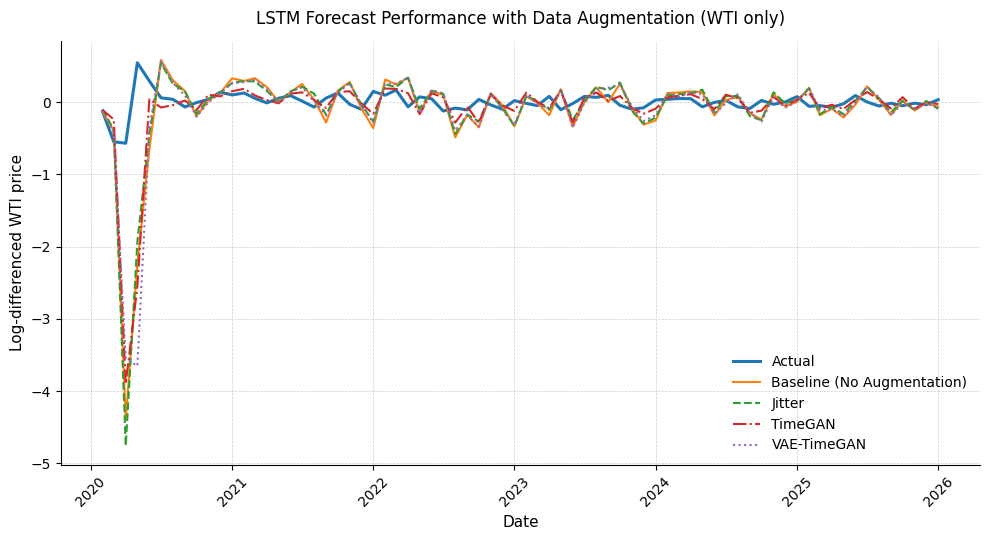

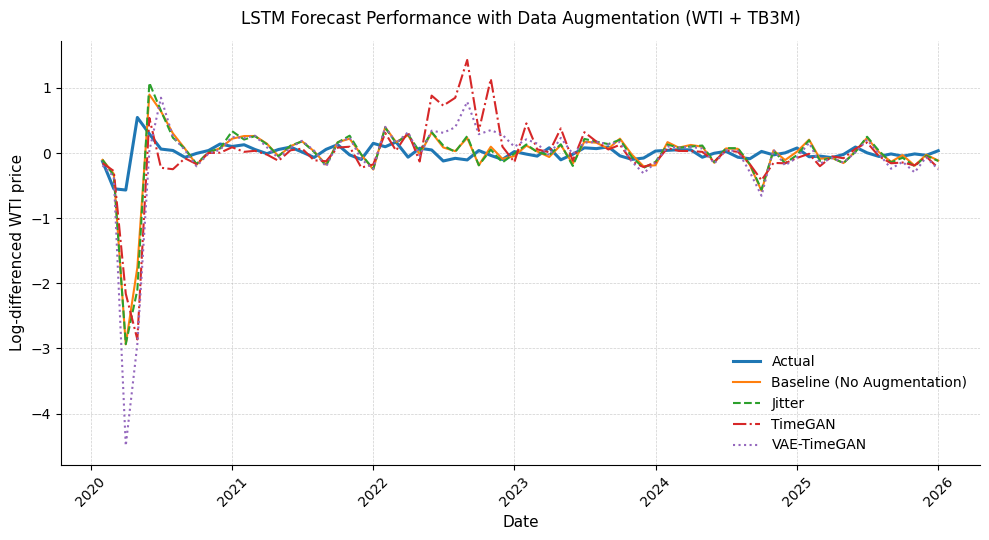

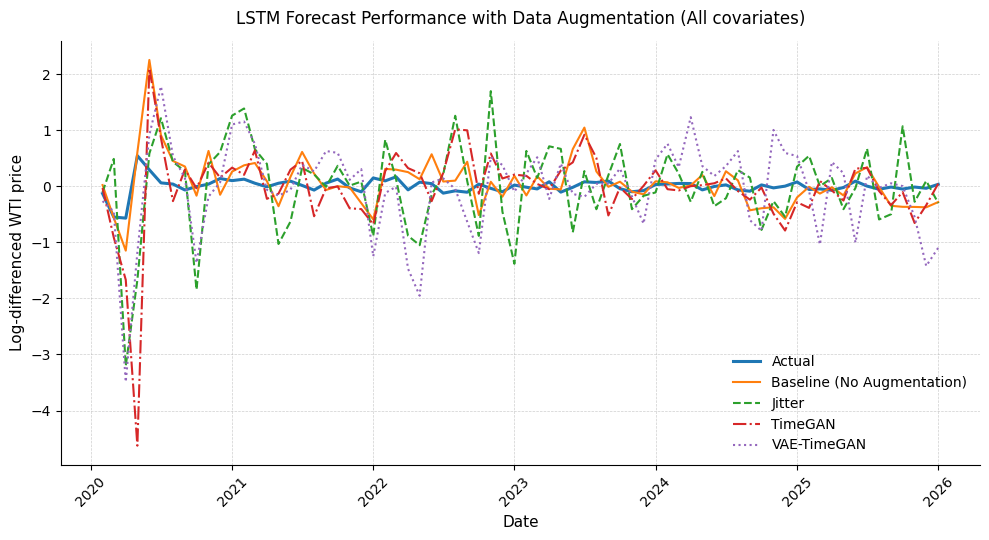

In [13]:
# =========================================================
# 5. Forecast comparison plots
# =========================================================

plot_forecast_comparison(
    df1,
    "LSTM Forecast Performance with Data Augmentation (WTI only)"
)

plot_forecast_comparison(
    df2,
    "LSTM Forecast Performance with Data Augmentation (WTI + TB3M)"
)

plot_forecast_comparison(
    df3,
    "LSTM Forecast Performance with Data Augmentation (All covariates)"
)

## 7. Forecast Accuracy Metrics: Full Sample

We now evaluate forecast accuracy over the full out-of-sample test period. For each specification, we compute:

- RMSE
- MAE
- Directional Accuracy (DA)

The benchmark model for each specification is included alongside the four LSTM variants. Results are sorted within each segment by RMSE so that the strongest-performing models appear first.

In [14]:
# =========================================================
# 6. Forecast accuracy metrics: full sample
# =========================================================

# LSTM metrics
metrics_df1 = compute_accuracy_metrics_from_wide_df(df1, actual_col="actual", model_cols=MODEL_COLS)
metrics_df2 = compute_accuracy_metrics_from_wide_df(df2, actual_col="actual", model_cols=MODEL_COLS)
metrics_df3 = compute_accuracy_metrics_from_wide_df(df3, actual_col="actual", model_cols=MODEL_COLS)

# Benchmark metrics
ar_metrics = compute_accuracy_metrics_from_results_df(ar_results, "AR(3)")
adl_metrics = compute_accuracy_metrics_from_results_df(adl_results, "ADL(1,1)")
full_adl_metrics = compute_accuracy_metrics_from_results_df(full_adl_results, "Full ADL")

# Append to corresponding segments
metrics_df1 = pd.concat([metrics_df1, ar_metrics], ignore_index=True)
metrics_df2 = pd.concat([metrics_df2, adl_metrics], ignore_index=True)
metrics_df3 = pd.concat([metrics_df3, full_adl_metrics], ignore_index=True)

# Add segment names
metrics_df1["Segment"] = "WTI only"
metrics_df2["Segment"] = "TB3M"
metrics_df3["Segment"] = "All covariates"

# Combine and sort
all_metrics = pd.concat([metrics_df1, metrics_df2, metrics_df3], ignore_index=True)
all_metrics = all_metrics[["Segment", "Model", "RMSE", "MAE", "Directional Accuracy (DA)"]]

segment_order = {"WTI only": 0, "TB3M": 1, "All covariates": 2}
all_metrics["segment_order"] = all_metrics["Segment"].map(segment_order)
all_metrics = (
    all_metrics
    .sort_values(["segment_order", "Segment", "RMSE"])
    .drop(columns="segment_order")
    .reset_index(drop=True)
)

print("Forecast accuracy metrics - full sample")
display(format_accuracy_metrics_table(all_metrics))

Forecast accuracy metrics - full sample


,Segment,Model,RMSE,MAE,Directional Accuracy (DA)
0,WTI only,AR(3),0.136,0.0806,62.5%
1,WTI only,timegan,0.551,0.1917,55.6%
2,WTI only,normal,0.605,0.2667,59.7%
3,WTI only,jitter,0.608,0.2501,58.3%
4,WTI only,vaetimegan,0.640,0.2565,56.9%
5,TB3M,"ADL(1,1)",0.137,0.0830,58.3%
6,TB3M,normal,0.436,0.2138,58.3%
7,TB3M,jitter,0.467,0.2226,58.3%
8,TB3M,timegan,0.556,0.2681,63.9%
9,TB3M,vaetimegan,0.667,0.2859,58.3%


## 7. Forecast Accuracy Metrics: Excluding the COVID Crash

To assess whether the extreme oil-price dislocation during the COVID-19 period drives the forecast results, we repeat the same evaluation after excluding observations from February 2020 to June 2020.

This robustness check allows us to compare model performance in a less crisis-driven environment and determine whether the relative ranking of models changes once the most volatile episode is removed.

In [15]:
# =========================================================
# 7. Forecast accuracy metrics: excluding COVID crash
# =========================================================

# LSTM ex-COVID
df1_ex_covid = filter_exclude_window(df1, COVID_START, COVID_END, date_col="date")
df2_ex_covid = filter_exclude_window(df2, COVID_START, COVID_END, date_col="date")
df3_ex_covid = filter_exclude_window(df3, COVID_START, COVID_END, date_col="date")

metrics_df1_ex_covid = compute_accuracy_metrics_from_wide_df(df1_ex_covid, actual_col="actual", model_cols=MODEL_COLS)
metrics_df2_ex_covid = compute_accuracy_metrics_from_wide_df(df2_ex_covid, actual_col="actual", model_cols=MODEL_COLS)
metrics_df3_ex_covid = compute_accuracy_metrics_from_wide_df(df3_ex_covid, actual_col="actual", model_cols=MODEL_COLS)

# Benchmark ex-COVID
ar_ex_covid = filter_exclude_window(ar_results, COVID_START, COVID_END, date_col="Date")
adl_ex_covid = filter_exclude_window(adl_results, COVID_START, COVID_END, date_col="Date")
full_adl_ex_covid = filter_exclude_window(full_adl_results, COVID_START, COVID_END, date_col="Date")

ar_metrics_ex_covid = compute_accuracy_metrics_from_results_df(ar_ex_covid, "AR(3)")
adl_metrics_ex_covid = compute_accuracy_metrics_from_results_df(adl_ex_covid, "ADL(1,1)")
full_adl_metrics_ex_covid = compute_accuracy_metrics_from_results_df(full_adl_ex_covid, "Full ADL")

# Append to corresponding segments
metrics_df1_ex_covid = pd.concat([metrics_df1_ex_covid, ar_metrics_ex_covid], ignore_index=True)
metrics_df2_ex_covid = pd.concat([metrics_df2_ex_covid, adl_metrics_ex_covid], ignore_index=True)
metrics_df3_ex_covid = pd.concat([metrics_df3_ex_covid, full_adl_metrics_ex_covid], ignore_index=True)

# Add segment names
metrics_df1_ex_covid["Segment"] = "WTI only"
metrics_df2_ex_covid["Segment"] = "TB3M"
metrics_df3_ex_covid["Segment"] = "All covariates"

# Combine and sort
all_metrics_ex_covid = pd.concat(
    [metrics_df1_ex_covid, metrics_df2_ex_covid, metrics_df3_ex_covid],
    ignore_index=True
)

all_metrics_ex_covid = all_metrics_ex_covid[["Segment", "Model", "RMSE", "MAE", "Directional Accuracy (DA)"]]
all_metrics_ex_covid["segment_order"] = all_metrics_ex_covid["Segment"].map(segment_order)

all_metrics_ex_covid = (
    all_metrics_ex_covid
    .sort_values(["segment_order", "Segment", "RMSE"])
    .drop(columns="segment_order")
    .reset_index(drop=True)
)

print("Forecast accuracy metrics - excluding COVID crash")
display(format_accuracy_metrics_table(all_metrics_ex_covid))

Forecast accuracy metrics - excluding COVID crash


,Segment,Model,RMSE,MAE,Directional Accuracy (DA)
0,WTI only,AR(3),0.070,0.0591,61.2%
1,WTI only,timegan,0.123,0.1013,53.7%
2,WTI only,jitter,0.189,0.1552,58.2%
3,WTI only,vaetimegan,0.192,0.1568,56.7%
4,WTI only,normal,0.210,0.1712,59.7%
5,TB3M,"ADL(1,1)",0.072,0.0603,56.7%
6,TB3M,normal,0.189,0.1473,56.7%
7,TB3M,jitter,0.191,0.1494,56.7%
8,TB3M,vaetimegan,0.257,0.1892,56.7%
9,TB3M,timegan,0.345,0.2054,62.7%


## 8. Trading Strategy Evaluation: Helper Functions

The next part of the notebook evaluates whether the model forecasts translate into economically meaningful trading performance.

To do so, we define a simple directional trading strategy in which monthly forecasts are converted into trading positions:

- long if the forecast is sufficiently positive
- short if the forecast is sufficiently negative
- flat otherwise

Strategy performance is then evaluated using annualized Sharpe ratio, annualized return, cumulative return, and maximum drawdown.

In [16]:
# =========================================================
# 8. Trading strategy evaluation helper functions
# =========================================================

def compute_positions(pred, threshold_mode="median_abs", fixed_threshold=None):
    """
    Convert predicted returns into positions.

    Rules:
    +1 if pred > threshold
    -1 if pred < -threshold
     0 otherwise
    """
    pred = pd.Series(pred).astype(float)

    if threshold_mode == "median_abs":
        threshold = pred.abs().median()
    elif threshold_mode == "fixed":
        if fixed_threshold is None:
            raise ValueError("fixed_threshold must be provided when threshold_mode='fixed'.")
        threshold = fixed_threshold
    elif threshold_mode == "sign":
        threshold = 0.0
    else:
        raise ValueError("threshold_mode must be 'median_abs', 'fixed', or 'sign'.")

    if threshold_mode == "sign":
        pos = np.where(pred > 0, 1.0, np.where(pred < 0, -1.0, 0.0))
    else:
        pos = np.where(pred > threshold, 1.0, np.where(pred < -threshold, -1.0, 0.0))

    return pd.Series(pos, index=pred.index), threshold


def backtest_strategy(actual, position, cost_rate=0.001):
    """
    Monthly trading backtest.

    Assumes prediction_t is aligned to actual_t.
    """
    actual = pd.Series(actual).astype(float)
    position = pd.Series(position, index=actual.index).astype(float)

    turnover = position.diff().abs().fillna(position.abs())
    gross_return = position * actual
    trading_cost = cost_rate * turnover
    net_return = gross_return - trading_cost

    wealth = (1.0 + net_return).cumprod()
    cum_return = wealth - 1.0

    return pd.DataFrame({
        "actual": actual,
        "position": position,
        "turnover": turnover,
        "gross_return": gross_return,
        "trading_cost": trading_cost,
        "net_return": net_return,
        "wealth": wealth,
        "cum_return": cum_return
    })


def performance_metrics(returns, periods_per_year=12):
    """
    Annual Sharpe, annual return, cumulative return, max drawdown.
    """
    r = pd.Series(returns).dropna()

    if len(r) == 0:
        return {
            "ann_sharpe": np.nan,
            "ann_return": np.nan,
            "cum_return": np.nan,
            "max_drawdown": np.nan
        }

    wealth = (1.0 + r).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1.0

    cum_return = wealth.iloc[-1] - 1.0
    ann_return = wealth.iloc[-1] ** (periods_per_year / len(r)) - 1.0

    mean_monthly = r.mean()
    vol_monthly = r.std(ddof=1)

    if vol_monthly == 0 or np.isnan(vol_monthly):
        ann_sharpe = np.nan
    else:
        ann_sharpe = (mean_monthly / vol_monthly) * np.sqrt(periods_per_year)

    max_drawdown = drawdown.min()

    return {
        "ann_sharpe": ann_sharpe,
        "ann_return": ann_return,
        "cum_return": cum_return,
        "max_drawdown": max_drawdown
    }


def run_trading_simulation(
    df,
    segment_name,
    threshold_mode="median_abs",
    fixed_thresholds=None,
    cost_rate=0.001,
    exclude_start=None,
    exclude_end=None,
    plot_results=True
):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    if exclude_start is not None and exclude_end is not None:
        df = filter_exclude_window(df, exclude_start, exclude_end, date_col="date")

    results = {}
    summary_rows = []

    # Buy-and-hold
    bh_position = pd.Series(1.0, index=df.index)
    bh_bt = backtest_strategy(actual=df[ACTUAL_COL], position=bh_position, cost_rate=0.0)
    results["buy_and_hold"] = bh_bt

    bh_metrics = performance_metrics(bh_bt["net_return"])
    summary_rows.append({
        "model": "buy_and_hold",
        **bh_metrics
    })

    # LSTM variants
    for col in MODEL_COLS:
        if threshold_mode == "fixed":
            if fixed_thresholds is None or col not in fixed_thresholds:
                raise ValueError(f"Missing fixed threshold for {col}.")
            pos, _ = compute_positions(df[col], threshold_mode="fixed", fixed_threshold=fixed_thresholds[col])
        else:
            pos, _ = compute_positions(df[col], threshold_mode=threshold_mode)

        bt = backtest_strategy(actual=df[ACTUAL_COL], position=pos, cost_rate=cost_rate)
        results[col] = bt

        metrics = performance_metrics(bt["net_return"])
        summary_rows.append({
            "model": col,
            **metrics
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_display = summary_df[["model", "ann_sharpe", "ann_return", "cum_return", "max_drawdown"]].copy()

    for c in ["ann_return", "cum_return", "max_drawdown"]:
        summary_display[c] = summary_display[c] * 100

    summary_display = summary_display.rename(columns={
        "ann_sharpe": "annual_sharpe",
        "ann_return": "annual_return_%",
        "cum_return": "cumulative_return_%",
        "max_drawdown": "max_drawdown_%"
    })

    plot_df = pd.DataFrame({"date": df["date"]})
    plot_df["buy_and_hold_cum"] = results["buy_and_hold"]["cum_return"].values
    plot_df["normal_cum"] = results["normal"]["cum_return"].values
    plot_df["jitter_cum"] = results["jitter"]["cum_return"].values
    plot_df["timegan_cum"] = results["timegan"]["cum_return"].values
    plot_df["vaetimegan_cum"] = results["vaetimegan"]["cum_return"].values

    plot_df["buy_and_hold_ret"] = results["buy_and_hold"]["net_return"].values
    plot_df["normal_ret"] = results["normal"]["net_return"].values
    plot_df["jitter_ret"] = results["jitter"]["net_return"].values
    plot_df["timegan_ret"] = results["timegan"]["net_return"].values
    plot_df["vaetimegan_ret"] = results["vaetimegan"]["net_return"].values

    if plot_results:
        plt.figure(figsize=(11, 6))
        plt.plot(plot_df["date"], plot_df["buy_and_hold_cum"], label="Buy and Hold", linewidth=2.2)
        plt.plot(plot_df["date"], plot_df["normal_cum"], label="Baseline", linewidth=1.5)
        plt.plot(plot_df["date"], plot_df["jitter_cum"], label="Jitter", linewidth=1.5, linestyle="--")
        plt.plot(plot_df["date"], plot_df["timegan_cum"], label="TimeGAN", linewidth=1.5, linestyle="-.")
        plt.plot(plot_df["date"], plot_df["vaetimegan_cum"], label="VAE-TimeGAN", linewidth=1.5, linestyle=":")
        plt.axhline(0, linewidth=0.8)
        plt.title(f"Cumulative Returns of Trading Strategies ({segment_name})")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Return")
        plt.legend(frameon=False)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(11, 6))
        plt.plot(plot_df["date"], plot_df["buy_and_hold_ret"], label="Buy and Hold", linewidth=2.0)
        plt.plot(plot_df["date"], plot_df["normal_ret"], label="Baseline", linewidth=1.2)
        plt.plot(plot_df["date"], plot_df["jitter_ret"], label="Jitter", linewidth=1.2, linestyle="--")
        plt.plot(plot_df["date"], plot_df["timegan_ret"], label="TimeGAN", linewidth=1.2, linestyle="-.")
        plt.plot(plot_df["date"], plot_df["vaetimegan_ret"], label="VAE-TimeGAN", linewidth=1.2, linestyle=":")
        plt.axhline(0, linewidth=0.8)
        plt.title(f"Monthly Returns of Trading Strategies ({segment_name})")
        plt.xlabel("Date")
        plt.ylabel("Monthly Return")
        plt.legend(frameon=False)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    return {
        "filtered_df": df,
        "summary": summary_display,
        "results": results,
        "plot_df": plot_df
    }

## 9. Trading Performance: Full Sample

This section runs the trading backtest on the full out-of-sample period for each of the three LSTM evaluation datasets. Each strategy is compared against a simple buy-and-hold benchmark.

For each specification, the notebook reports the summary trading metrics and produces two plots:

- cumulative return over time
- monthly strategy returns

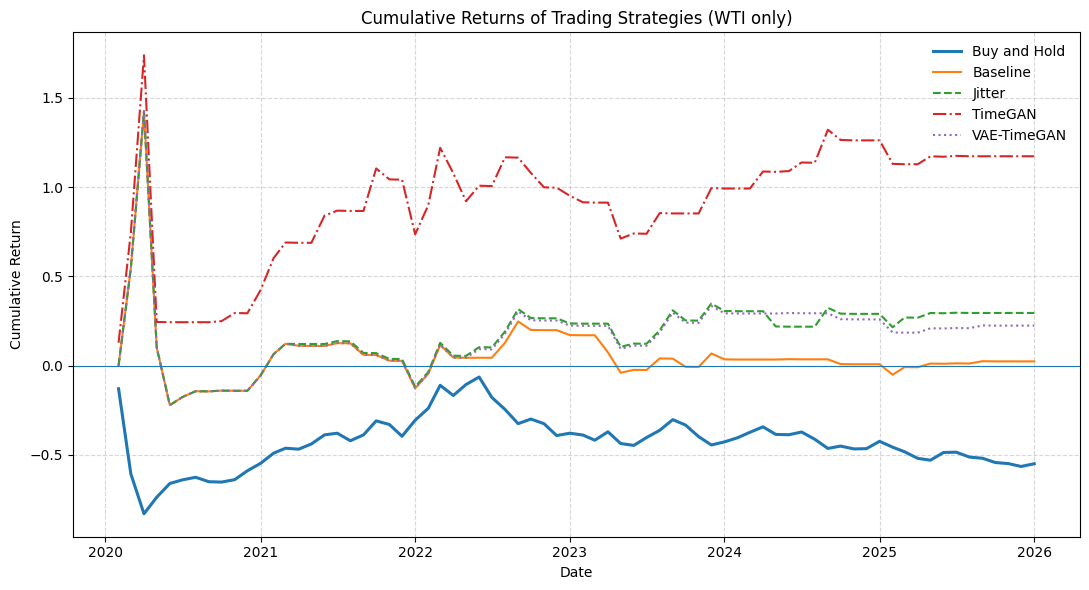

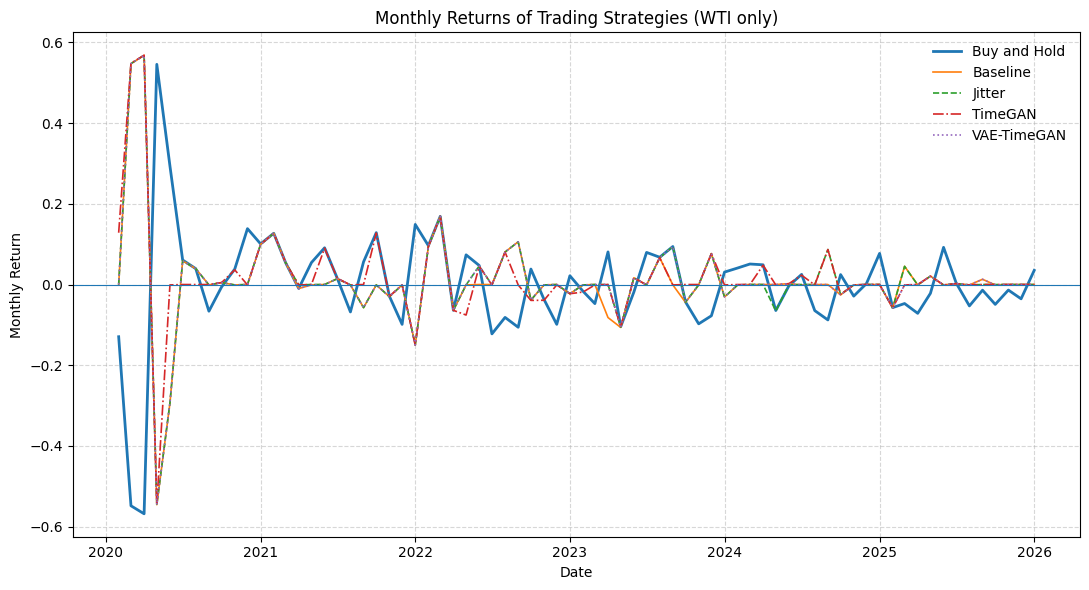

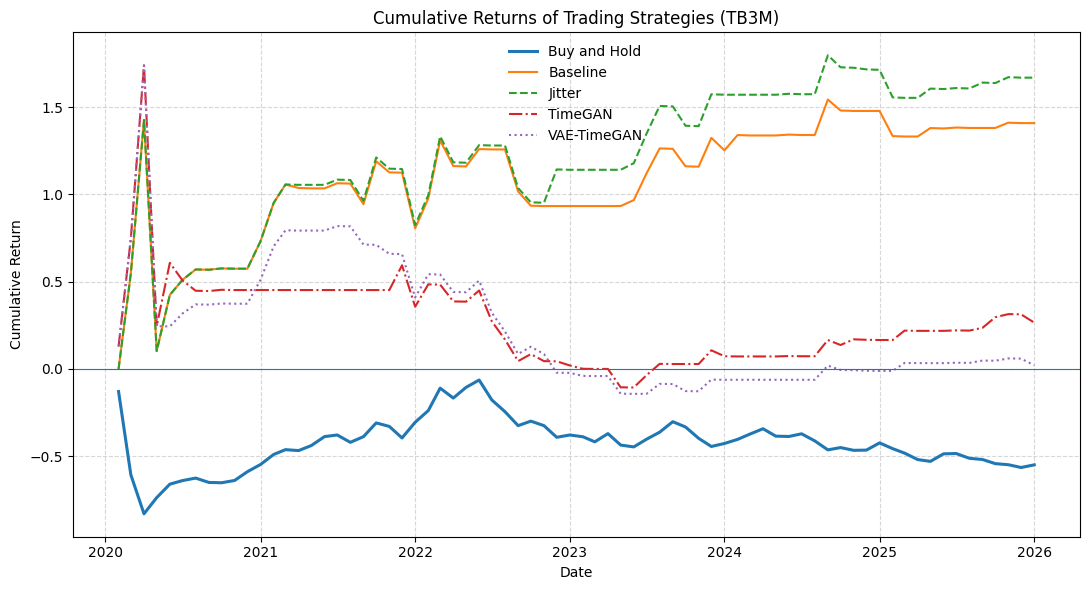

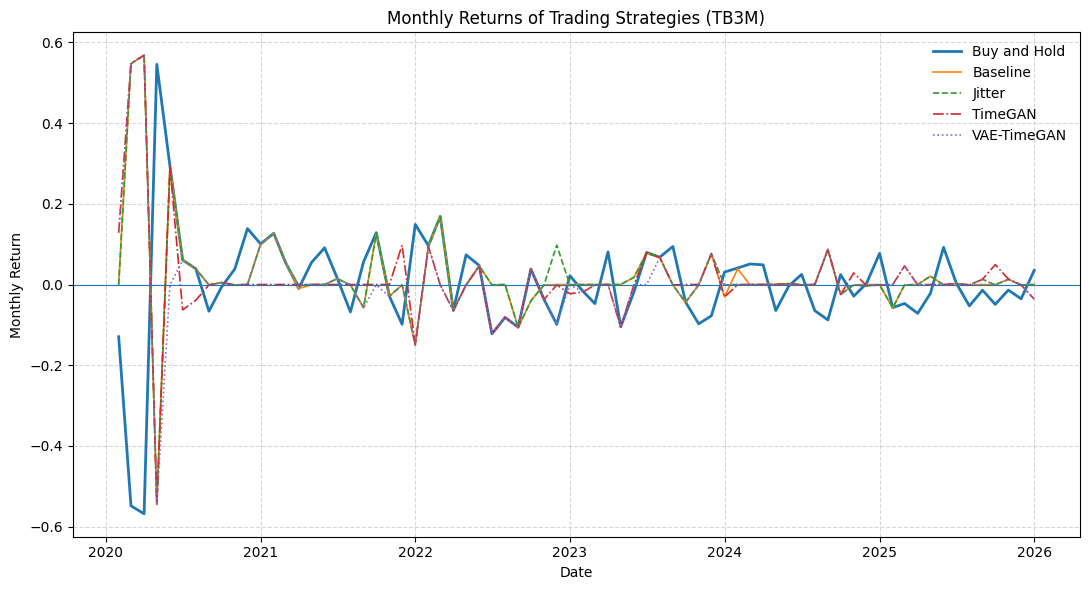

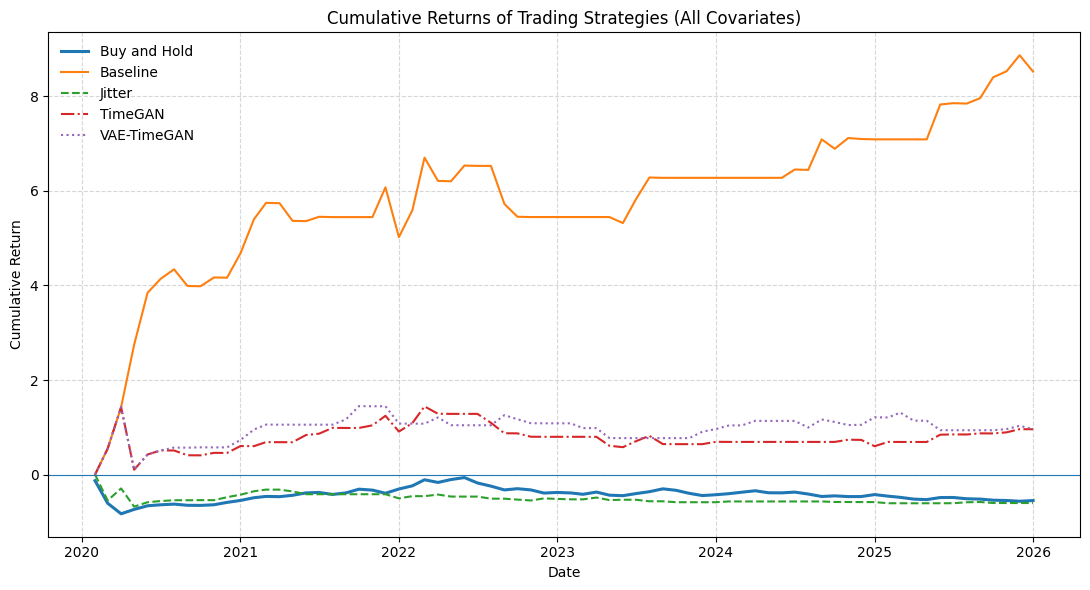

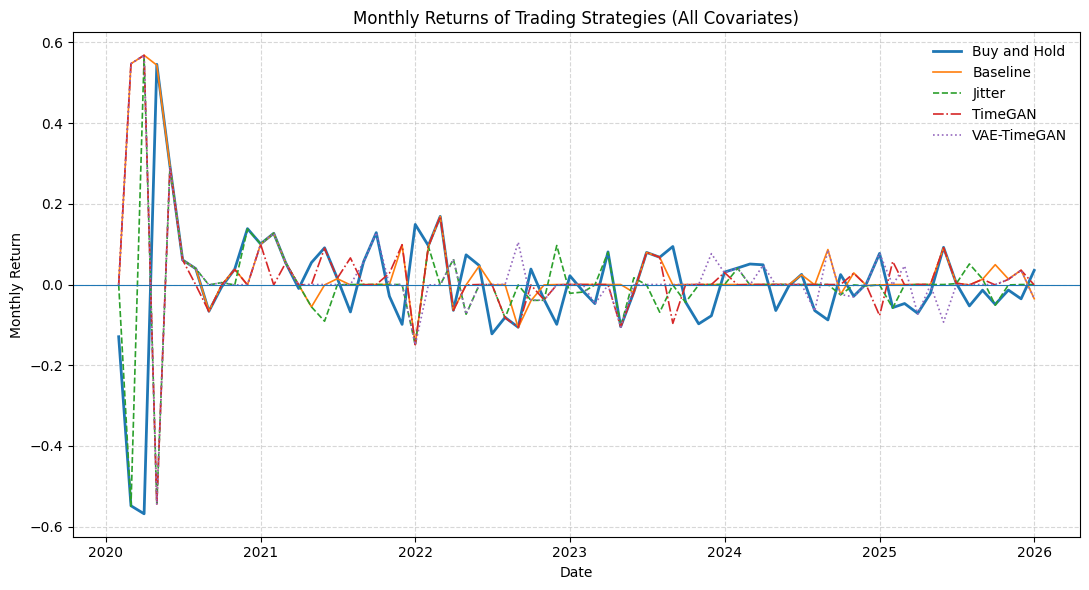

Trading performance summary - WTI only


,model,annual_sharpe,annual_return_%,cumulative_return_%,max_drawdown_%
0,buy_and_hold,0.0149,-12.4501,-54.9667,-80.4902
1,normal,0.2366,0.3966,2.4032,-67.9074
2,jitter,0.3262,4.4074,29.5350,-67.9074
3,timegan,0.5217,13.8136,117.3521,-54.6075
4,vaetimegan,0.3042,3.4300,22.4275,-67.9074


Trading performance summary - TB3M


,model,annual_sharpe,annual_return_%,cumulative_return_%,max_drawdown_%
0,buy_and_hold,0.0149,-12.4501,-54.9667,-80.4902
1,normal,0.5570,15.7779,140.8538,-54.5621
2,jitter,0.5965,17.7755,166.8889,-54.5621
3,timegan,0.3104,3.9999,26.5311,-67.3801
4,vaetimegan,0.2256,0.3442,2.0832,-68.7096


Trading performance summary - All covariates


,model,annual_sharpe,annual_return_%,cumulative_return_%,max_drawdown_%
0,buy_and_hold,0.0149,-12.4501,-54.9667,-80.4902
1,normal,1.0628,45.5890,852.2962,-17.9682
2,jitter,-0.0743,-14.2458,-60.2321,-67.9243
3,timegan,0.4773,11.8514,95.8159,-54.5621
4,vaetimegan,0.4780,11.8694,96.0052,-54.5621


In [17]:
# =========================================================
# 9. Trading strategy evaluation: full sample
# =========================================================

wti_full = run_trading_simulation(
    df=df1,
    segment_name="WTI only",
    threshold_mode="median_abs",
    cost_rate=0.001,
    plot_results=True
)

tb3m_full = run_trading_simulation(
    df=df2,
    segment_name="TB3M",
    threshold_mode="median_abs",
    cost_rate=0.001,
    plot_results=True
)

allcov_full = run_trading_simulation(
    df=df3,
    segment_name="All Covariates",
    threshold_mode="median_abs",
    cost_rate=0.001,
    plot_results=True
)

print("Trading performance summary - WTI only")
display(wti_full["summary"].round(4))

print("Trading performance summary - TB3M")
display(tb3m_full["summary"].round(4))

print("Trading performance summary - All covariates")
display(allcov_full["summary"].round(4))

## 10. Trading Performance: Excluding the COVID Crash

As a robustness check, we rerun the same trading simulation after removing the COVID-19 crash window from February 2020 to June 2020.

This helps assess whether the trading results are mainly driven by extreme crisis-period moves or whether the relative ranking of strategies persists under more typical market conditions.

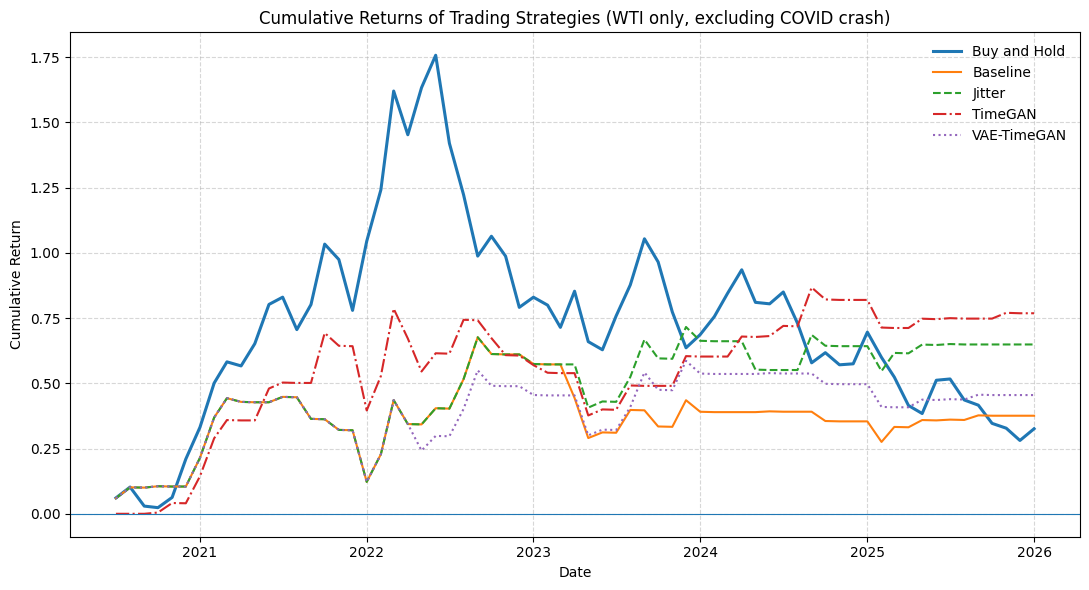

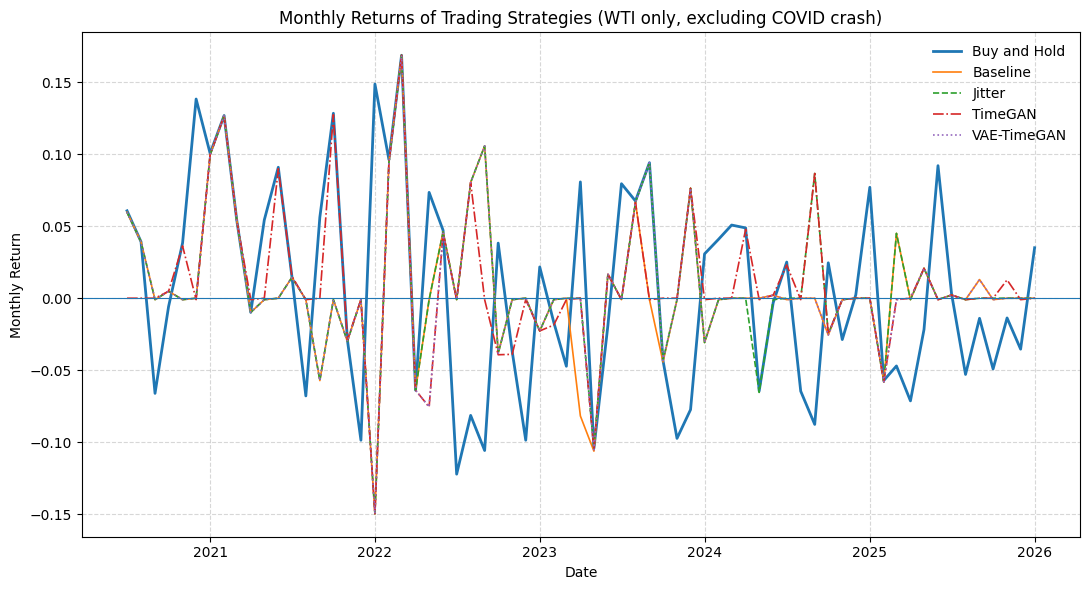

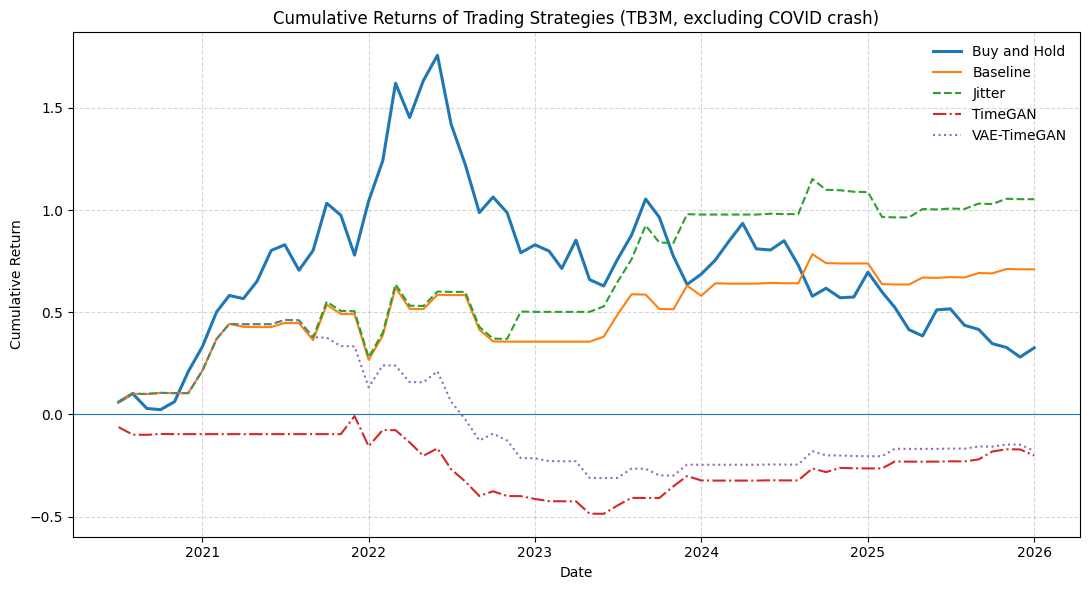

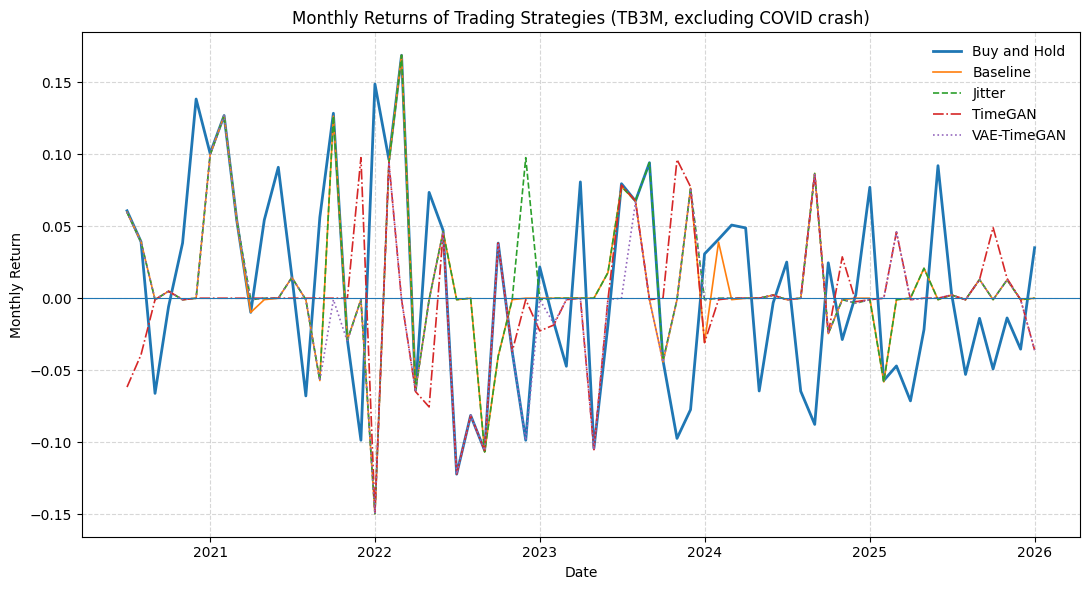

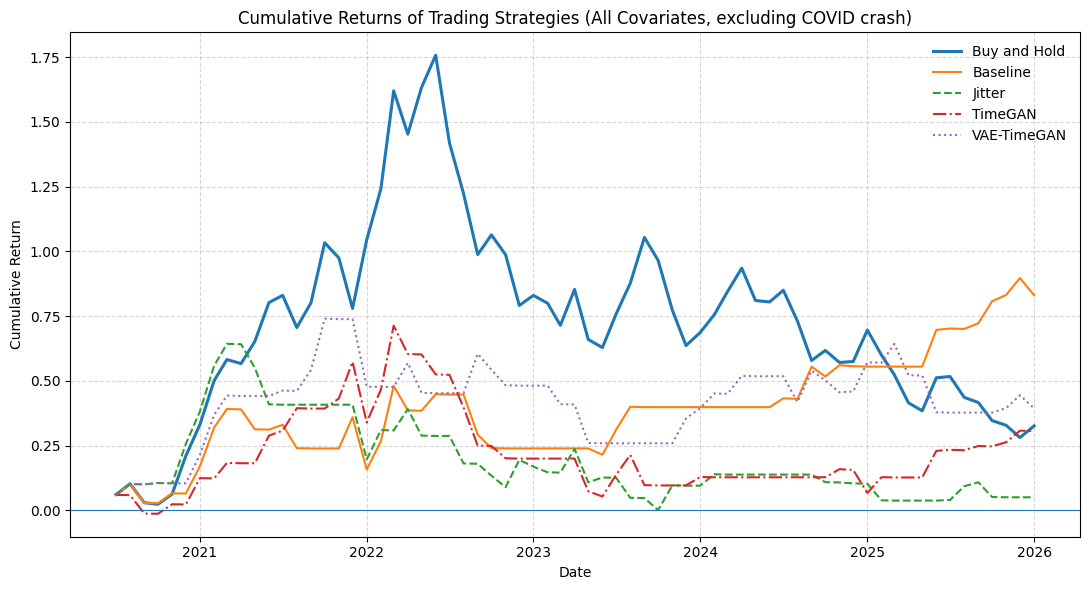

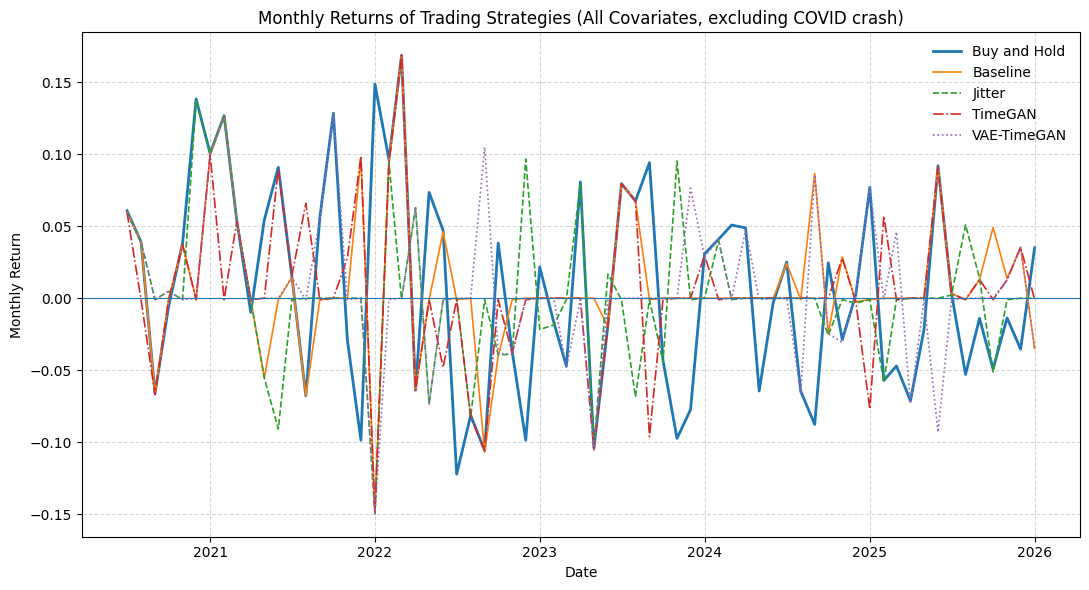

Trading performance summary - WTI only, excluding COVID


,model,annual_sharpe,annual_return_%,cumulative_return_%,max_drawdown_%
0,buy_and_hold,0.3250,5.1821,32.5895,-53.5360
1,normal,0.4186,5.8798,37.5749,-23.9262
2,jitter,0.5955,9.3689,64.8760,-22.4924
3,timegan,0.6711,10.7490,76.8331,-22.9007
4,vaetimegan,0.4730,6.9460,45.4909,-22.4924


Trading performance summary - TB3M, excluding COVID


,model,annual_sharpe,annual_return_%,cumulative_return_%,max_drawdown_%
0,buy_and_hold,0.3250,5.1821,32.5895,-53.5360
1,normal,0.6460,10.0851,70.9952,-17.5348
2,jitter,0.8156,13.7495,105.2978,-17.5348
3,timegan,-0.1624,-3.9339,-20.0750,-48.1641
4,vaetimegan,-0.1229,-3.4532,-17.8162,-52.8613


Trading performance summary - All covariates, excluding COVID


,model,annual_sharpe,annual_return_%,cumulative_return_%,max_drawdown_%
0,buy_and_hold,0.3250,5.1821,32.5895,-53.5360
1,normal,0.7146,11.4332,83.0198,-17.9682
2,jitter,0.1365,0.8851,5.0429,-39.0738
3,timegan,0.3536,4.9021,30.6306,-38.5134
4,vaetimegan,0.4341,6.1238,39.3550,-27.6484


In [18]:
# =========================================================
# 10. Trading strategy evaluation: excluding COVID crash
# =========================================================

wti_ex_covid = run_trading_simulation(
    df=df1,
    segment_name="WTI only, excluding COVID crash",
    threshold_mode="median_abs",
    cost_rate=0.001,
    exclude_start=COVID_START,
    exclude_end=COVID_END,
    plot_results=True
)

tb3m_ex_covid = run_trading_simulation(
    df=df2,
    segment_name="TB3M, excluding COVID crash",
    threshold_mode="median_abs",
    cost_rate=0.001,
    exclude_start=COVID_START,
    exclude_end=COVID_END,
    plot_results=True
)

allcov_ex_covid = run_trading_simulation(
    df=df3,
    segment_name="All Covariates, excluding COVID crash",
    threshold_mode="median_abs",
    cost_rate=0.001,
    exclude_start=COVID_START,
    exclude_end=COVID_END,
    plot_results=True
)

print("Trading performance summary - WTI only, excluding COVID")
display(wti_ex_covid["summary"].round(4))

print("Trading performance summary - TB3M, excluding COVID")
display(tb3m_ex_covid["summary"].round(4))

print("Trading performance summary - All covariates, excluding COVID")
display(allcov_ex_covid["summary"].round(4))